In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_csv("train_mnist.csv")
test = pd.read_csv("test_mnist.csv")

print("Shape:", train.shape)
print("Nb colonnes:", len(train.columns))
print("Colonnes:", train.columns.tolist()[:20], "...")
print(train.head(2))


print("\nShape:", test.shape)
print("Nb colonnes:", len(test.columns))
print("Colonnes:", test.columns.tolist()[:20], "...")
print(test.head(2))

Shape: (30000, 787)
Nb colonnes: 787
Colonnes: ['Unnamed: 0', 'label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10', '1x11', '1x12', '1x13', '1x14', '1x15', '1x16', '1x17', '1x18'] ...
   Unnamed: 0  label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  ...  28x20  \
0           0      5    0    0    0    0    0    0    0    0  ...      0   
1           1      0    0    0    0    0    0    0    0    0  ...      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28     id  
0      0      0      0      0      0      0      0      0  AAAAA  
1      0      0      0      0      0      0      0      0  AAAAB  

[2 rows x 787 columns]

Shape: (40000, 786)
Nb colonnes: 786
Colonnes: ['Unnamed: 0', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10', '1x11', '1x12', '1x13', '1x14', '1x15', '1x16', '1x17', '1x18', '1x19'] ...
   Unnamed: 0  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x20  28x21  \
0       30000    0    0    0    0    0    0  

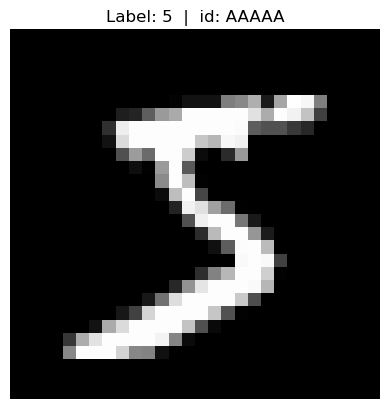

In [ ]:
# pixels = colonnes type "1x1", "1x2", ..., "28x28"
pixel_cols = [c for c in train.columns if "x" in c and c.split("x")[0].isdigit() and c.split("x")[1].isdigit()]

# tri ligne, colonne
pixel_cols = sorted(pixel_cols, key=lambda s: (int(s.split("x")[0]), int(s.split("x")[1])))

X = train[pixel_cols].to_numpy()
y = train["label"].to_numpy()

i = 0
img = X[i].reshape(28, 28)

plt.imshow(img, cmap="gray")
plt.title(f"Label: {y[i]}  |  id: {train.loc[i, 'id']}")
plt.axis("off")
plt.show()

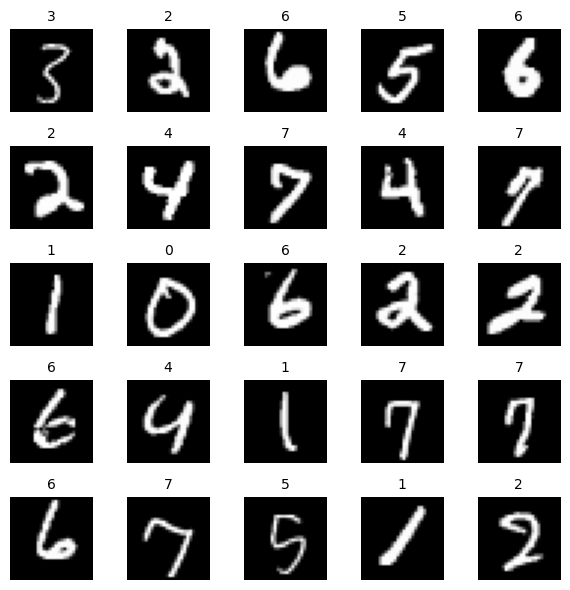

In [31]:
n = 25
idx = np.random.choice(len(train), n, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, j in zip(axes.ravel(), idx):
    ax.imshow(X[j].reshape(28, 28), cmap="gray")
    ax.set_title(str(y[j]), fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 1) Hyperparamètres
alpha = 0.1             # learning rate : taille des pas de descente de gradient
hidden = 64             # nb de neurones dans la couche cachée
dropout_percent = 0.2   # probabilité de "drop" un neurone (0.2 = on coupe 20%)
do_dropout = True       # activer/désactiver dropout
epochs = 30             # nb de passages complets sur le dataset
batch_size = 256        # taille des mini-lots (plus stable + plus rapide)
best_acc = -1

def sigmoid(x):
    """
    Activation couche cachée.
    Sortie dans (0,1). Non-linéarité.
    On clip x pour éviter overflow dans exp() si x est grand.
    """
    x = np.clip(x, -50, 50)
    output = 1 / (1 + np.exp(-x))
    return output

def deriv(x):
    """
    Dérivée de sigmoid, MAIS on la calcule en fonction de 'a' = sigmoid(x).
    d/dx sigmoid(x) = a*(1-a)
    """
    output = x * (1-x)
    return output

def softmax(z):
    """
    Convertit des scores (logits) en probabilités qui somment à 1.
    z: (batch, 10)
    Astuce stabilité numérique : soustraire max par ligne avant exp.
    """
    z= z -z.max(axis=1, keepdims= True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims= True)

def one_hot(y, k=10):
    """
    y: labels entiers 0..9 (shape: (N,))
    retourne une matrice Y (N,10) avec 1 à la classe correcte.
    """
    Y = np.zeros((len(y), k), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y

def dropout_mask(shape, p):
    """
    Inverted dropout mask.
    - On garde chaque neurone avec proba (1-p).
    - On divise par (1-p) pour garder la même espérance d'activation.
    shape: (batch, hidden)
    retourne mask de même shape.
    """
    m = (np.random.rand(*shape) > p).astype(np.float32) # 1 si gardé, 0 si drop
    return m / (1-p)

# X doit être (N, 784) et float
X = train[pixel_cols].to_numpy().astype(np.float32) / 255.0 # (N, 784)
y = train["label"].to_numpy().astype(int)
Y = one_hot(y, 10) #(N, 1O)

np.random.seed(1)

# W0 : poids entrée -> couche cachée
# shape: (784, hidden) car 784 features entrent dans chaque neurone caché
W0 = 0.01 * np.random.randn(784, hidden).astype(np.float32)

# b0 : biais de la couche cachée (1 valeur par neurone caché)
# shape: (1, hidden) pour broadcast correct sur (batch, hidden)
b0 = np.zeros((1, hidden), dtype=np.float32)

# W1 : poids couche cachée -> sortie (10 classes)
# shape: (hidden, 10)
W1 = 0.01 * np.random.randn(hidden, 10).astype(np.float32)

# b1 : biais de sortie (1 valeur par classe)
# shape: (1, 10) IMPORTANT (sinon erreur de broadcast)
b1 = np.zeros((1, 10), dtype=np.float32)

N = len(X)

# Vérification shapes
print("X:", X.shape)    # (N,784)
print("W0:", W0.shape)  # (784,hidden)
print("b0:", b0.shape)  # (1,hidden)
print("W1:", W1.shape)  # (hidden,10)
print("b1:", b1.shape)  # (1,10)


for ep in range(epochs):
    # On mélange les indices à chaque epoch pour casser les patterns d'ordre
    perm = np.random.permutation(N)
    Xp, Yp = X[perm], Y[perm]

    for start in range(0, N, batch_size):
        xb = Xp[start:start+batch_size]
        yb = Yp[start:start+batch_size]
        m = len(xb) # taille réelle du batch (dernier batch parfois < batch_size)

        # forward propagation:

        # Couche cachée : z1 = xb @ W0 + b0
        # - xb: (m,784)
        # - W0: (784,hidden)
        # -> z1: (m,hidden)
        z1 = xb @ W0 + b0
        a1 = sigmoid(z1) # Activation cachée : a1 = sigmoid(z1) -> (m,hidden)

        if do_dropout :
            # Mask même shape que a1. Exemple: 20% des neurones coupés.
            m1 = dropout_mask(a1.shape, dropout_percent)
            a1 *= m1 # applique dropout sur les activations

        # Sortie : logits z2 = a1 @ W1 + b1
        # - a1: (m,hidden)
        # - W1: (hidden,10)
        # -> z2: (m,10)
        z2 = a1 @ W1 + b1
        p = softmax(z2) # Probabilités par classe : p = softmax(z2) -> (m,10)

        # backward propagation (cross-entropy + softmax) :
        dz2 = (p - yb) / m

        # Gradients sur W1 et b1
        # dW1 = a1^T @ dz2
        # - a1^T: (hidden,m)
        # - dz2:  (m,10)
        # -> dW1: (hidden,10)
        dW1 = a1.T @ dz2
        db1 = dz2.sum(axis=0, keepdims=True) # db1 = somme sur les lignes (batch) -> (1,10)

        # Backprop vers couche cachée :
        # da1 = dz2 @ W1^T
        # - dz2: (m,10)
        # - W1^T: (10,hidden)
        # -> da1: (m,hidden)
        da1 = dz2 @ W1.T

        # Si dropout, on doit appliquer le MÊME mask au gradient
        # (sinon on "réanimes" des neurones coupés pendant le forward)
        if do_dropout:
            da1 *= m1

        # dz1 = da1 * sigmoid'(z1)
        # Mais on a deriv(a1) car a1 = sigmoid(z1)
        dz1 = da1 * deriv(a1)

        # Gradients sur W0 et b0
        # dW0 = xb^T @ dz1
        # - xb^T: (784,m)
        # - dz1:  (m,hidden)
        # -> dW0: (784,hidden)
        dW0 = xb.T @ dz1
        db0 = dz1.sum(axis = 0, keepdims= True)  # db0 = somme batch -> (1,hidden)

        # UPDATE (descente de gradient)
        W1 -= alpha * dW1
        b1 -= alpha * db1
        W0 -= alpha * dW0
        b0 -= alpha * db0

    # 6) Monitoring : accuracy train
    preds = np.argmax(softmax(sigmoid(X @ W0 + b0) @ W1 + b1), axis = 1)
    acc = (preds == y).mean()
    if acc > best_acc:
        best_acc = acc
        best = {"W0": W0.copy(), "b0": b0.copy(), "W1": W1.copy(), "b1": b1.copy()}
    print(f"epoch {ep+1}/{epochs} | acc(train)= {acc:.3f}")

epoch 1/30 | acc(train)= 0.117
epoch 2/30 | acc(train)= 0.443
epoch 3/30 | acc(train)= 0.592
epoch 4/30 | acc(train)= 0.696
epoch 5/30 | acc(train)= 0.787
epoch 6/30 | acc(train)= 0.816
epoch 7/30 | acc(train)= 0.840
epoch 8/30 | acc(train)= 0.856
epoch 9/30 | acc(train)= 0.866
epoch 10/30 | acc(train)= 0.876
epoch 11/30 | acc(train)= 0.883
epoch 12/30 | acc(train)= 0.887
epoch 13/30 | acc(train)= 0.891
epoch 14/30 | acc(train)= 0.895
epoch 15/30 | acc(train)= 0.899
epoch 16/30 | acc(train)= 0.901
epoch 17/30 | acc(train)= 0.902
epoch 18/30 | acc(train)= 0.905
epoch 19/30 | acc(train)= 0.905
epoch 20/30 | acc(train)= 0.907
epoch 21/30 | acc(train)= 0.909
epoch 22/30 | acc(train)= 0.910
epoch 23/30 | acc(train)= 0.911
epoch 24/30 | acc(train)= 0.912
epoch 25/30 | acc(train)= 0.913
epoch 26/30 | acc(train)= 0.914
epoch 27/30 | acc(train)= 0.915
epoch 28/30 | acc(train)= 0.917
epoch 29/30 | acc(train)= 0.918
epoch 30/30 | acc(train)= 0.919


In [26]:
alpha = 0.05
hidden = 32
dropout_percent = 0.2
do_dropout = True

def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))

def deriv_sigmoid(x):
    return 1 * (1-x)

def dropout_mask(shape, p):
    m = (np.random.rand(*shape) > p).astype(np.float32)
    return m / (1 -p)

X = train[pixel_cols].to_numpy().astype(np.float32) / 255.0
y = (train["label"].to_numpy() == 5).astype(np.float32).reshape(-1, 1)

np.random.seed(1)

syn0 = 0.01 * np.random.randn(784, hidden).astype(np.float32)
syn1 = 0.01 * np.random.randn(hidden, 10).astype(np.float32)

for j in range(10000):
    layer0 = X                          #(N, 784)
    layer1 = sigmoid(layer0 @ syn0)     #(N, hidden)

    if do_dropout:
        m1 = dropout_mask(layer1.shape, dropout_percent)
        layer1 *= m1

    layer2 = sigmoid(layer1 @ syn1)

    layer2_error = layer2 - Y
    if j%1000 == 0:
        print(j, "MAE:", np.mean(np.abs(layer2_error)))

    layer2_delta = layer2_error * deriv_sigmoid(layer2)
    layer1_error = layer2_delta @ syn1.T
    layer1_delta = layer1_error * deriv_sigmoid(layer1)

    if do_dropout:
        layer1_delta *= m1
    
    syn1 -= alpha * (layer1.T @ layer2_delta) / len(X)
    syn0 -= alpha * (layer0.T @ layer1_delta) / len(X)

0 MAE: 0.49982938
1000 MAE: 0.17413948
2000 MAE: 0.14875945
3000 MAE: 0.12832406
4000 MAE: 0.11693695
5000 MAE: 0.10904005
6000 MAE: 0.102507256
7000 MAE: 0.09706311
8000 MAE: 0.09369784
9000 MAE: 0.09134823


In [42]:
def predict_proba(X, W0, b0, W1, b1):
    a1 = sigmoid(X @ W0 + b0)
    p = softmax(a1 @ W1 + b1)
    return p

def predict(X, W0, b0, W1, b1):
    return np.argmax(predict_proba(X, W0, b0, W1, b1), axis = 1)


pixel_cols_test = [c for c in test.columns if "x" in c and c.split("x")[0].isdigit() and c.split("x")[1].isdigit()]
pixel_cols_test = sorted(pixel_cols_test, key=lambda s: (int(s.split("x")[0]), int(s.split("x")[1])))

X_test = test[pixel_cols_test].to_numpy()

y_pred = predict(X_test, best["W0"], best["b0"], best["W1"], best["b1"])

submission = test[["id"]].copy()
submission["label"] = y_pred
submission.to_csv("submission.csv", index=False)